# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 861
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,ed54d81,1.219543,6.9,KEEP,baseline current default config
1,7496692,1.230511,8.8,DISCARD,increase depth from 6 to 8
2,bd0682b,1.213172,6.9,KEEP,increase matrix LR from 0.04 to 0.06
3,12c9d48,1.212913,6.9,KEEP,increase matrix LR from 0.06 to 0.08
4,38be0b0,1.213196,6.9,DISCARD,increase matrix LR from 0.08 to 0.10 (too high)
5,e16d10e,1.212223,6.9,KEEP,increase embedding LR from 0.6 to 0.8
6,5545276,1.309385,6.9,DISCARD,double total batch size to 2^20 (too few steps)
7,0d551e7,1.206655,6.9,KEEP,halve total batch size to 2^18 for more steps
8,f1b2d14,1.183821,6.9,KEEP,halve total batch size to 2^17
9,1703c1c,1.131772,6.8,KEEP,halve total batch size to 2^16


In [6]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    777
KEEP        68
CRASH       14

Keep rate: 68/845 = 8.0%


In [7]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (68 total):

  #  0  bpb=1.219543  mem=6.9GB  baseline current default config
  #  2  bpb=1.213172  mem=6.9GB  increase matrix LR from 0.04 to 0.06
  #  3  bpb=1.212913  mem=6.9GB  increase matrix LR from 0.06 to 0.08
  #  5  bpb=1.212223  mem=6.9GB  increase embedding LR from 0.6 to 0.8
  #  7  bpb=1.206655  mem=6.9GB  halve total batch size to 2^18 for more steps
  #  8  bpb=1.183821  mem=6.9GB  halve total batch size to 2^17
  #  9  bpb=1.131772  mem=6.8GB  halve total batch size to 2^16
  # 12  bpb=1.128085  mem=6.8GB  increase warmdown ratio from 0.5 to 0.7
  # 13  bpb=1.125932  mem=6.8GB  increase warmdown ratio from 0.7 to 0.9
  # 14  bpb=1.119729  mem=6.8GB  reduce weight decay from 0.2 to 0.1
  # 18  bpb=1.118501  mem=6.8GB  double unembedding LR from 0.004 to 0.008
  # 22  bpb=1.117739  mem=6.8GB  increase scalar LR from 0.5 to 1.0
  # 27  bpb=1.117194  mem=6.8GB  warmdown ratio 1.0 (pure cosine decay)
  # 35  bpb=1.116886  mem=6.8GB  reduce matrix LR from 0.

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

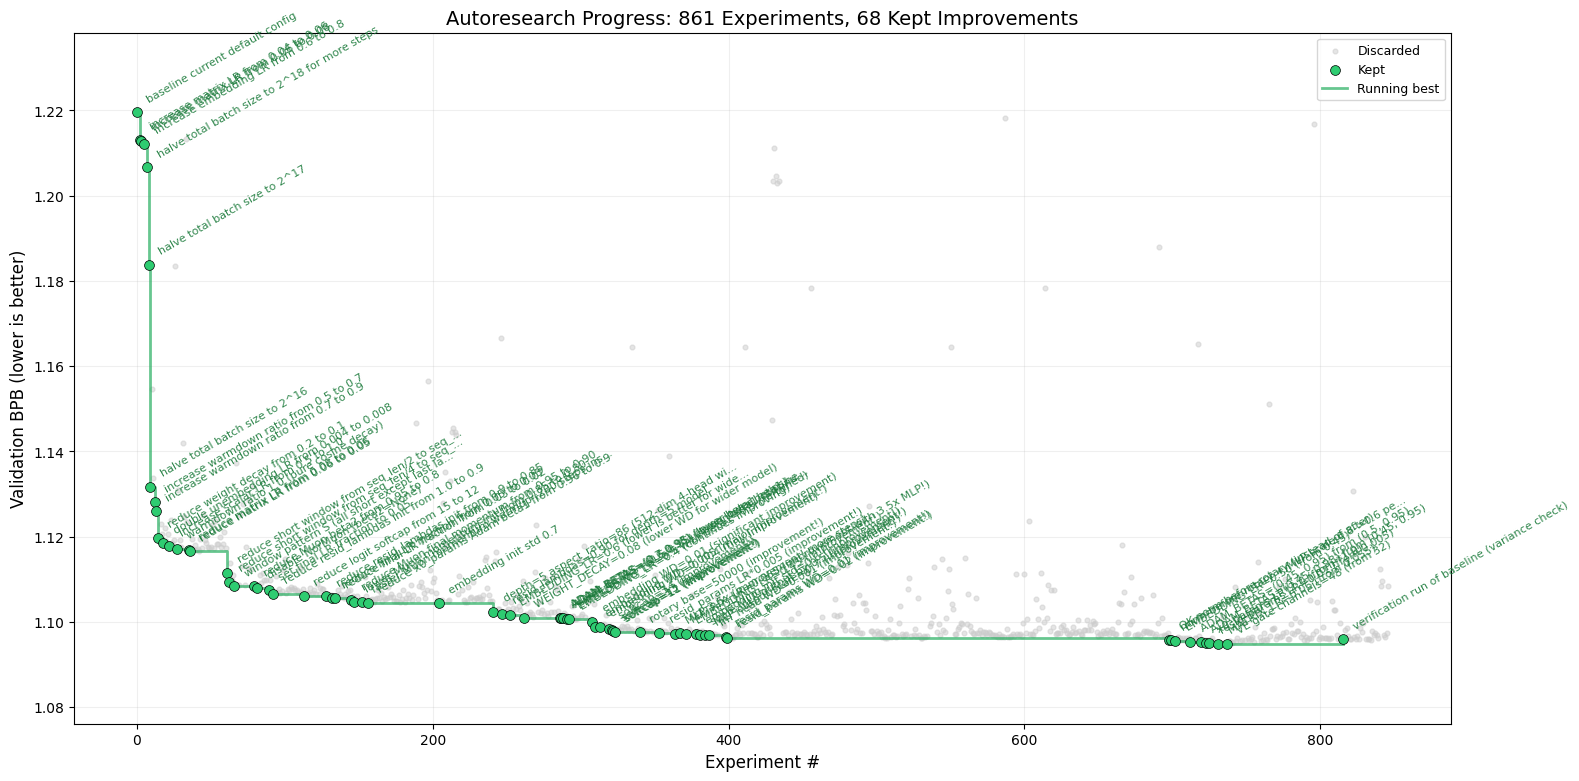

Saved to progress.png


In [8]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
best_bpb = kept_bpb.min()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
margin = max((baseline_bpb - best_bpb) * 0.15, 1e-4)
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [9]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.219543
Best val_bpb:      1.094845
Total improvement: 0.124698 (10.22%)
Best experiment:   VE gate channels=48 (from 32)

Cumulative effort per improvement:
  Experiment #  0: bpb=1.219543  baseline current default config
  Experiment #  2: bpb=1.213172  increase matrix LR from 0.04 to 0.06
  Experiment #  3: bpb=1.212913  increase matrix LR from 0.06 to 0.08
  Experiment #  5: bpb=1.212223  increase embedding LR from 0.6 to 0.8
  Experiment #  7: bpb=1.206655  halve total batch size to 2^18 for more steps
  Experiment #  8: bpb=1.183821  halve total batch size to 2^17
  Experiment #  9: bpb=1.131772  halve total batch size to 2^16
  Experiment # 12: bpb=1.128085  increase warmdown ratio from 0.5 to 0.7
  Experiment # 13: bpb=1.125932  increase warmdown ratio from 0.7 to 0.9
  Experiment # 14: bpb=1.119729  reduce weight decay from 0.2 to 0.1
  Experiment # 18: bpb=1.118501  double unembedding LR from 0.004 to 0.008
  Experiment # 22: bpb=1.117739  increase scalar 

## Top Hits (Kept Experiments by Improvement)

In [10]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.052049  1.131772  halve total batch size to 2^16
   2  +0.022834  1.183821  halve total batch size to 2^17
   3  +0.006371  1.213172  increase matrix LR from 0.04 to 0.06
   4  +0.006203  1.119729  reduce weight decay from 0.2 to 0.1
   5  +0.005568  1.206655  halve total batch size to 2^18 for more steps
   6  +0.004991  1.111608  reduce short window from seq_len/2 to seq_len/4
   7  +0.003687  1.128085  increase warmdown ratio from 0.5 to 0.7
   8  +0.002220  1.109388  reduce short window from seq_len/4 to seq_len/8
   9  +0.002153  1.125932  increase warmdown ratio from 0.7 to 0.9
  10  +0.001914  1.102453  depth=5 aspect_ratio=86 (512-dim 4-head wider model)
  11  +0.001228  1.118501  double unembedding LR from 0.004 to 0.008
  12  +0.001144  1.098883  embedding WD=0.005 (major improvement!)
  13  +0.000987  1.108401  window pattern S (all short except l